In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error # Equivalent to Brier Score in this scenario

import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

# Print current working directory
print(f"Current working directory: {os.getcwd()}")

# List files in the current directory
print("Files in current directory:", os.listdir())

# Check if the data directory exists
if os.path.exists('march-machine-learning-mania-2026'):
    print("Directory exists!")
    os.chdir('march-machine-learning-mania-2026')
else:
    print("Directory does not exist!")

print(os.listdir())

Current working directory: /home/josef-lin/march-madness
Files in current directory: ['.gitignore', 'march-machine-learning-mania-2026', '.git', 'elo.ipynb', 'README.md', 'march-machine-learning-mania-2025', 'march-machine-learning-mania-2026.zip']
Directory exists!
['MNCAATourneySlots.csv', 'MRegularSeasonCompactResults.csv', 'MMasseyOrdinals.csv', 'MNCAATourneyDetailedResults.csv', 'MGameCities.csv:Zone.Identifier', 'MNCAATourneySeeds.csv:Zone.Identifier', 'MNCAATourneyDetailedResults.csv:Zone.Identifier', 'SampleSubmissionStage1.csv', 'MSeasons.csv', 'MRegularSeasonDetailedResults.csv', 'WRegularSeasonDetailedResults.csv', 'MConferenceTourneyGames.csv', 'WTeamSpellings.csv:Zone.Identifier', 'WTeams.csv:Zone.Identifier', 'MTeamSpellings.csv', 'MNCAATourneyCompactResults.csv', 'MNCAATourneySlots.csv:Zone.Identifier', 'WNCAATourneyDetailedResults.csv', 'Cities.csv', 'WRegularSeasonCompactResults.csv', 'WTeams.csv', 'MTeamCoaches.csv:Zone.Identifier', 'WTeamConferences.csv:Zone.Identifi

In [2]:
# Load Data
tourney_results = pd.concat([
    pd.read_csv("MNCAATourneyCompactResults.csv"),
    pd.read_csv("WNCAATourneyCompactResults.csv"),
], ignore_index=True) \
    .assign(League = lambda x: np.where(x['WTeamID'] < 3000, 1, 0))

regular_results = pd.concat([
    pd.read_csv("MRegularSeasonCompactResults.csv"),
    pd.read_csv("WRegularSeasonCompactResults.csv"),
], ignore_index=True) \
    .assign(League = lambda x: np.where(x['WTeamID'] < 3000, 1, 0))

teams_df = pd.concat([
    pd.read_csv('MTeams.csv'),
    pd.read_csv('WTeams.csv') \
        .assign(TeamName = lambda x: x['TeamName'] + " - Womens"),
], ignore_index=True) \
    .assign(League = lambda x: np.where(x['TeamID'] < 3000, 1, 0))

display(tourney_results.head())
display(regular_results.head())
display(teams_df)

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,League
0,1985,136,1116,63,1234,54,N,0,1
1,1985,136,1120,59,1345,58,N,0,1
2,1985,136,1207,68,1250,43,N,0,1
3,1985,136,1229,58,1425,55,N,0,1
4,1985,136,1242,49,1325,38,N,0,1


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,League
0,1985,20,1228,81,1328,64,N,0,1
1,1985,25,1106,77,1354,70,H,0,1
2,1985,25,1112,63,1223,56,H,0,1
3,1985,25,1165,70,1432,54,H,0,1
4,1985,25,1192,86,1447,74,H,0,1


,TeamID,TeamName,FirstD1Season,LastD1Season,League
0,1101,Abilene Chr,2014.0,2026.0,1
1,1102,Air Force,1985.0,2026.0,1
2,1103,Akron,1985.0,2026.0,1
3,1104,Alabama,1985.0,2026.0,1
4,1105,Alabama A&M,2000.0,2026.0,1
...,...,...,...,...,...
755,3477,East Texas A&M - Womens,NaN,NaN,0
756,3478,Le Moyne - Womens,NaN,NaN,0
757,3479,Mercyhurst - Womens,NaN,NaN,0
758,3480,West Georgia - Womens,NaN,NaN,0


In [3]:
# These utility functions are used to create a similar format to the final submission format.
def add_id(df):
    df['LowTeamID'] = df[['WTeamID', 'LTeamID']].min(axis=1) 
    df['HighTeamID'] = df[['WTeamID', 'LTeamID']].max(axis=1)
    df['ID'] = df['Season'].astype('str') + '_' + df['LowTeamID'].astype('str') + "_" + df['HighTeamID'].astype('str')
    df.drop(['LowTeamID', 'HighTeamID'], axis=1, inplace=True)
    return df

def id_to_teams(df):
    df['LowTeamID'] = df['ID'].str.split('_', expand=True)[1].astype('int')
    df['HighTeamID'] = df['ID'].str.split('_', expand=True)[2].astype('int')
    return df

def prep_tourney(df):
    df = df.copy()
    df = add_id(df)
    df = id_to_teams(df)
    df['Actual'] = np.where(df['WTeamID'] == df['LowTeamID'], 1, 0)
    return df[['ID', 'Season', 'LowTeamID', 'HighTeamID', 'Actual']]

prep_tourney(tourney_results).sample(20) # sampling to get a better look at the data

,ID,Season,LowTeamID,HighTeamID,Actual
3515,2012_3124_3210,2012,3124,3210,1
419,1991_1113_1116,1991,1113,1116,0
3364,2010_3328_3355,2010,3328,3355,1
3314,2009_3314_3345,2009,3314,3345,0
1635,2010_1165_1246,2010,1165,1246,0
754,1996_1280_1393,1996,1280,1393,0
2389,2023_1116_1228,2023,1116,1228,1
2333,2022_1231_1388,2022,1231,1388,0
1544,2009_1277_1352,2009,1277,1352,1
3569,2013_3166_3397,2013,3166,3397,0


In [4]:
# Basic Elo
class Elo:
    def __init__(self, default_rating=1000, k=50, scale_factor=400): # these are my starting ratings
        self.default_rating = default_rating # this value
        self.k = k
        self.scale_factor = scale_factor
    
    def calc_prob(self, rating_a, rating_b):
        prob_a = 1 / (1 + 10 ** ((rating_b - rating_a) / self.scale_factor))
        prob_b = 1 - prob_a
        return prob_a, prob_b
    
    def update_ratings(self, rating_a, rating_b, outcome):
        prob_a, prob_b = self.calc_prob(rating_a, rating_b)
        rating_a_new = rating_a + self.k * (outcome - prob_a)
        rating_b_new = rating_b + self.k * ((1 - outcome) - prob_b)
        return rating_a_new, rating_b_new
    
    def calc_rating_history(self, df, teams_df):
        df = df.copy()
        # 'Date' is a psuedo date used to show progression within a season and year
        # without the long gaps. This is just one way of simplifying that.
        df['Date'] = df['DayNum'] + 154 * (df['Season'] - df['Season'].min()) 
        
        ids = pd.concat([df['WTeamID'], df['LTeamID']]).unique()
        team_ratings = dict.fromkeys(ids, self.default_rating)
        ratings_history = []
        
        for _, row in df.iterrows():
            team_a = row.WTeamID
            team_b = row.LTeamID
            date = row.Date
            
            a_new, b_new = self.update_ratings(team_ratings[team_a], team_ratings[team_b], outcome=1)
            team_ratings[team_a] = a_new
            team_ratings[team_b] = b_new
        
            ratings_history.append({'Season': row['Season'], 'DayNum': row['DayNum'], 'Date': date, 'TeamID': team_a, 'Rating': a_new})
            ratings_history.append({'Season': row['Season'], 'DayNum': row['DayNum'], 'Date': date, 'TeamID': team_b, 'Rating': b_new})
        
        r_history = pd.DataFrame(ratings_history)
        r_history = r_history.merge(teams_df[['TeamID', 'TeamName']], on='TeamID', how='left')
        r_history['GameType'] = np.where(r_history['DayNum'] <= 132, 'Regular', 'Tourney')
        return r_history
    
    def pre_tourney_ratings(self, r_history):
        return (r_history.loc[r_history['GameType'] == 'Regular']
                .sort_values(['Season', 'TeamID', 'Date'])
                .groupby(['Season', 'TeamID'], as_index=False)['Rating']
                .last())
    
    def add_elo(self, df, elo_df):
        df = df.merge(elo_df, how='left', left_on=['Season', 'LowTeamID'], right_on=['Season', 'TeamID'])
        df = df.merge(elo_df, how='left', left_on=['Season', 'HighTeamID'], right_on=['Season', 'TeamID'])
        df = df.drop(['TeamID_x', 'TeamID_y'], axis=1)
        df = df.rename(columns={'Rating_x': 'EloRating_x', 'Rating_y': 'EloRating_y'})
        df['EloPred'] = df.apply(lambda x: self.calc_prob(x['EloRating_x'], x['EloRating_y'])[0], axis=1)
        return df
    
    def eval_elo(self, games_df, teams_df, tourney_df):
        r_history = self.calc_rating_history(games_df, teams_df=teams_df)
        pre_tourney_df = self.pre_tourney_ratings(r_history)
        tourney_df = self.add_elo(tourney_df, pre_tourney_df)
        tourney_df['Brier'] = (tourney_df['Actual'] - tourney_df['EloPred']) ** 2
        return tourney_df
    
tourney_df = (
    prep_tourney(tourney_results)
)

e = Elo(k=27, scale_factor=224)
season_scores = e.eval_elo(games_df=regular_results, teams_df=teams_df, tourney_df=tourney_df).groupby('Season', as_index=False)['Brier'].mean()
print('Mean Brier: ', season_scores['Brier'].mean())
season_scores.query('Season > 2003')


Mean Brier:  0.1737019511338302


,Season,Brier
19,2004,0.173565
20,2005,0.163381
21,2006,0.174178
22,2007,0.161018
23,2008,0.140121
24,2009,0.154309
25,2010,0.169333
26,2011,0.184256
27,2012,0.144658
28,2013,0.182744


In [5]:
# Install first: pip install scikit-optimize
from skopt import gp_minimize
from skopt.space import Real, Integer

def evaluate_params(k, scale_factor, regular_results, tourney_results, teams_df):
    """Evaluate Elo model with given parameters"""
    e = Elo(k=k, scale_factor=scale_factor)
    tourney_df_processed = prep_tourney(tourney_results)
    result = e.eval_elo(games_df=regular_results, teams_df=teams_df, tourney_df=tourney_df_processed)
    # Only consider results after 2000 for evaluation
    return result[result['Season'] > 2000]['Brier'].mean()

def objective(params):
    k, scale_factor = params
    return evaluate_params(k, scale_factor, regular_results, tourney_results, teams_df)

# Define search space
space = [Integer(10, 80, name='k'),
         Integer(150, 800, name='scale_factor')]

# Perform Bayesian optimization
result = gp_minimize(objective, space, n_calls=30, random_state=42, verbose=True)

print(f"Best parameters: k={result.x[0]}, scale_factor={result.x[1]}")
print(f"Best Brier score: {result.fun:.5f}")

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 114.3959
Function value obtained: 0.1686
Current minimum: 0.1686
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 70.2554
Function value obtained: 0.1650
Current minimum: 0.1650
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 60.9805
Function value obtained: 0.1663
Current minimum: 0.1650
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 79.1728
Function value obtained: 0.1650
Current minimum: 0.1650
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 74.9646
Function value obtained: 0.1740
Current minimum: 0.1650
Iteration No: 6 started. Eval

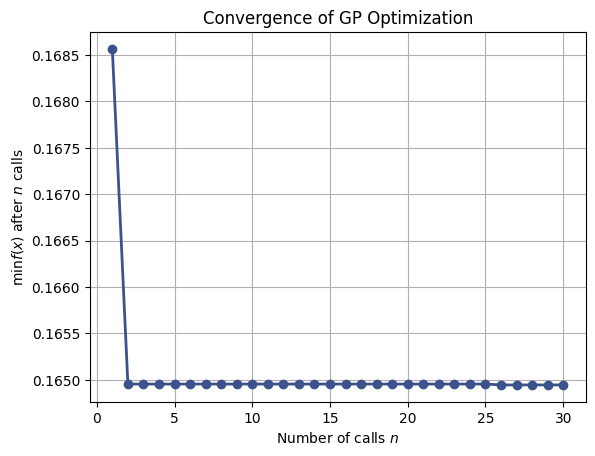

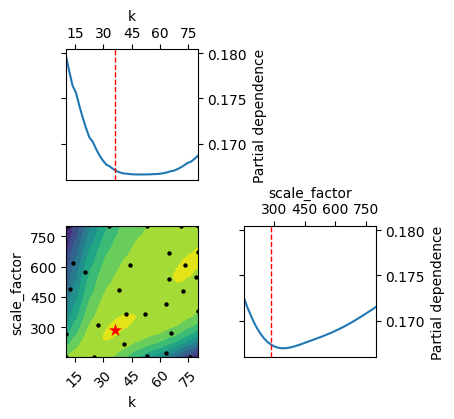

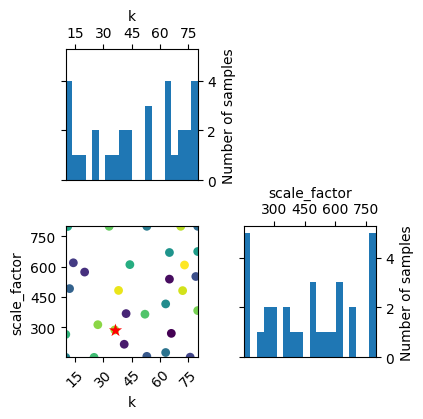

In [6]:
from skopt.plots import plot_convergence, plot_objective, plot_evaluations

# After running gp_minimize
# 1. Plot convergence over iterations
_ = plot_convergence(result)
plt.title('Convergence of GP Optimization')
plt.show()

# 2. Plot objective function and parameter relationships
_ = plot_objective(result)
plt.show()

# 3. Plot all evaluations
_ = plot_evaluations(result)
plt.show()

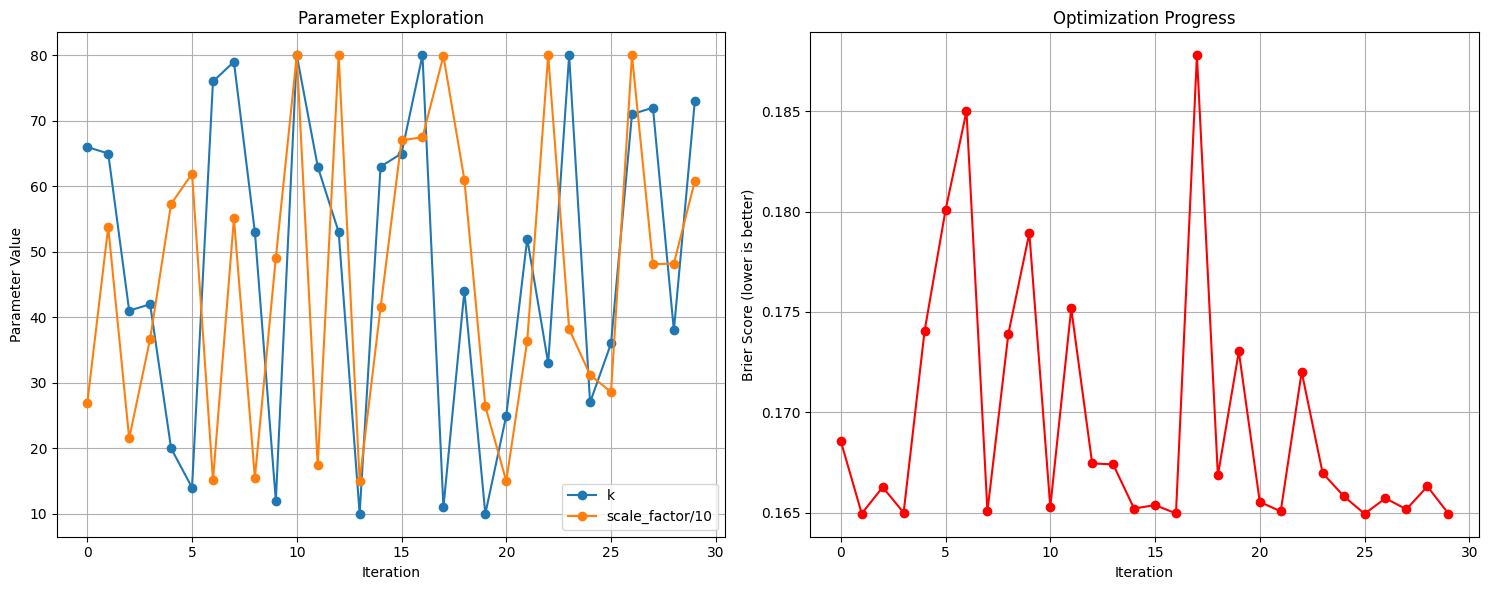

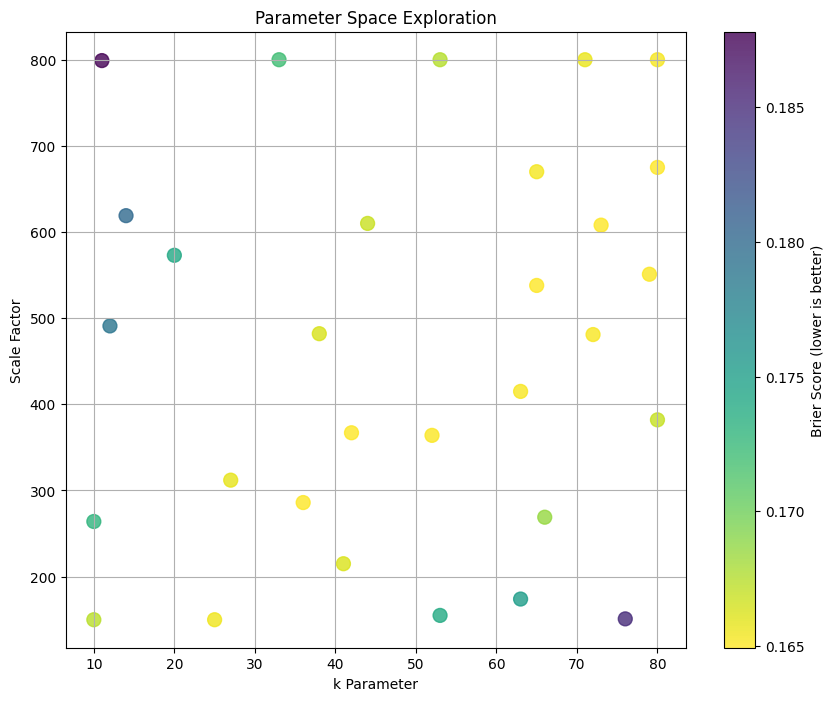

In [7]:
# Extract data from optimization result
params_df = pd.DataFrame({
    'iteration': range(len(result.func_vals)),
    'k': [x[0] for x in result.x_iters],
    'scale_factor': [x[1] for x in result.x_iters],
    'brier_score': result.func_vals
})

# Plot optimization progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Parameter values during optimization
ax1.plot(params_df['iteration'], params_df['k'], 'o-', label='k')
ax1.plot(params_df['iteration'], params_df['scale_factor']/10, 'o-', label='scale_factor/10')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Parameter Value')
ax1.legend()
ax1.set_title('Parameter Exploration')
ax1.grid(True)

# Brier score progression
ax2.plot(params_df['iteration'], params_df['brier_score'], 'o-', color='red')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Brier Score (lower is better)')
ax2.set_title('Optimization Progress')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Create heatmap of results
plt.figure(figsize=(10, 8))
plt.scatter(
    params_df['k'], 
    params_df['scale_factor'], 
    c=params_df['brier_score'],
    cmap='viridis_r',  # reversed so darker = better
    s=100,
    alpha=0.8
)
plt.colorbar(label='Brier Score (lower is better)')
plt.xlabel('k Parameter')
plt.ylabel('Scale Factor')
plt.title('Parameter Space Exploration')
plt.grid(True)
plt.show()

In [8]:
# Create Elo model with optimized parameters
best_k, best_scale_factor = result.x
final_elo = Elo(k=best_k, scale_factor=best_scale_factor)

# Calculate full ratings history
ratings_history = final_elo.calc_rating_history(df=regular_results, teams_df=teams_df)

# Option 1: Export full ratings history
ratings_history.to_csv('elo_ratings_history.csv', index=False)
print("Full ratings history exported to 'elo_ratings_history.csv'")

# Option 2: Export only pre-tournament ratings (usually what you want for predictions)
pre_tourney = final_elo.pre_tourney_ratings(ratings_history)
pre_tourney.to_csv('elo_pre_tournament_ratings.csv', index=False)
print("Pre-tournament ratings exported to 'elo_pre_tournament_ratings.csv'")

# Option 3: Export final ratings for most recent season only (for 2026 predictions)
latest_season = pre_tourney['Season'].max()
latest_ratings = pre_tourney[pre_tourney['Season'] == latest_season]
latest_ratings.to_csv(f'elo_ratings_{latest_season}.csv', index=False)
print(f"Latest season ({latest_season}) ratings exported to 'elo_ratings_{latest_season}.csv'")

Full ratings history exported to 'elo_ratings_history.csv'
Pre-tournament ratings exported to 'elo_pre_tournament_ratings.csv'
Latest season (2026) ratings exported to 'elo_ratings_2026.csv'


In [9]:
# Load the latest pre-tournament ratings for 2026
latest_ratings = pd.read_csv('elo_ratings_2026.csv')

# Separate men's and women's teams based on ID
mens_teams = [team for team in latest_ratings['TeamID'].unique() if str(team).startswith('1')]
womens_teams = [team for team in latest_ratings['TeamID'].unique() if str(team).startswith('3')]

print(f"Found {len(mens_teams)} men's teams and {len(womens_teams)} women's teams")

# Generate matchups only between teams of the same gender
matchups = []

# Men's matchups
for i, team1 in enumerate(mens_teams):
    for team2 in mens_teams[i+1:]:
        low_id = min(team1, team2)
        high_id = max(team1, team2)
        matchup_id = f"2026_{low_id}_{high_id}"
        matchups.append(matchup_id)
        
# Women's matchups
for i, team1 in enumerate(womens_teams):
    for team2 in womens_teams[i+1:]:
        low_id = min(team1, team2)
        high_id = max(team1, team2)
        matchup_id = f"2026_{low_id}_{high_id}"
        matchups.append(matchup_id)

men_matchups = len(mens_teams) * (len(mens_teams)-1) // 2
women_matchups = len(womens_teams) * (len(womens_teams)-1) // 2
print(f"Generated {len(matchups)} possible matchups ({men_matchups} men's + {women_matchups} women's)")

# Create the submission dataframe
submission = pd.DataFrame({'ID': matchups})

# Create a dictionary of team ratings for quick lookup
team_ratings = dict(zip(latest_ratings['TeamID'], latest_ratings['Rating']))

# Function to calculate win probability using your optimized Elo parameters
def predict_matchup(row, ratings_dict, k=result.x[0], scale_factor=result.x[1]):
    # Extract TeamIDs from the ID string
    season, low_id, high_id = row['ID'].split('_')
    low_id, high_id = int(low_id), int(high_id)
    
    # Get Elo ratings for both teams
    rating_low = ratings_dict[low_id]
    rating_high = ratings_dict[high_id]
    
    # Calculate probability using Elo formula
    prob_low_wins = 1 / (1 + 10 ** ((rating_high - rating_low) / scale_factor))
    return prob_low_wins

# Calculate predictions for each matchup
submission['Pred'] = submission.apply(predict_matchup, axis=1, ratings_dict=team_ratings)

# Save the submission file
submission.to_csv('elo_submission_2026.csv', index=False)

print(f"Submission file created with {len(submission)} predictions.")
print("First few predictions:")
print(submission.head())

Found 365 men's teams and 363 women's teams


Generated 132133 possible matchups (66430 men's + 65703 women's)
Submission file created with 132133 predictions.
First few predictions:
               ID      Pred
0  2026_1101_1102  0.739882
1  2026_1101_1103  0.061656
2  2026_1101_1104  0.013076
3  2026_1101_1105  0.753359
4  2026_1101_1106  0.831477


In [10]:
import random
import pandas as pd
import time
import re

def load_data():
    try:
        # Load ratings file
        ratings = pd.read_csv('elo_ratings_2026.csv')
        
        # Load team name files
        men_teams = pd.read_csv('MTeams.csv')
        women_teams = pd.read_csv('WTeams.csv')
        
        # Add women's suffix to match your data format
        women_teams['TeamName'] = women_teams['TeamName'] + " - Womens"
        
        # Combine team data
        teams = pd.concat([men_teams, women_teams], ignore_index=True)
        
        # Load submission file with probabilities
        submission = pd.read_csv('elo_submission_2026.csv')
        
        # Create dictionary for quick lookup
        submission_dict = {}
        for _, row in submission.iterrows():
            submission_dict[row['ID']] = row['Pred']
        
        # Create dictionaries for team lookups
        team_name_to_id = dict(zip(teams['TeamName'].str.lower(), teams['TeamID']))
        team_id_to_name = dict(zip(teams['TeamID'], teams['TeamName']))
            
        return team_name_to_id, team_id_to_name, submission_dict
            
    except Exception as e:
        print(f"Error loading data: {e}")
        print("Make sure MTeams.csv and WTeams.csv are available in your data folder.")
        return {}, {}, {}

# Load the data
team_name_to_id, team_id_to_name, submission_dict = load_data()

def find_team_id(team_input):
    """Try to match team input to a team ID"""
    # Try direct lookup first
    if team_input.lower() in team_name_to_id:
        return team_name_to_id[team_input.lower()]
    
    # Try partial match
    matches = [name for name in team_name_to_id.keys() if team_input.lower() in name]
    if len(matches) == 1:
        return team_name_to_id[matches[0]]
    elif len(matches) > 1:
        print(f"Multiple matches found: {', '.join([name for name in matches])}")
        return None
    
    # Try ID
    if team_input.isdigit():
        team_id = int(team_input)
        if team_id in team_id_to_name:
            return team_id
    
    # Not found
    return None

def predict_score(win_probability, avg_total_points=140):
    """Convert win probability to predicted score"""
    # Convert probability to log-odds, then to point differential
    # Research suggests ~3.5 point spread per 100 Elo points
    # With scale_factor around 224-558, this gives reasonable spreads
    import math
    if win_probability == 0.5:
        point_spread = 0
    else:
        point_spread = 15 * math.log(win_probability / (1 - win_probability))
    
    # Calculate team scores based on point spread and average total
    team1_score = avg_total_points/2 + point_spread/2
    team2_score = avg_total_points/2 - point_spread/2
    
    # Round to nearest whole number
    team1_score = int(round(team1_score))
    team2_score = int(round(team2_score))
    
    return team1_score, team2_score

def predict_winner():
    print("\n🏀 MARCH MADNESS MATCHUP PREDICTOR 🏀")
    print("Enter team name or ID (or 'q' to quit)")
    
    while True:
        # Get team inputs
        team1_input = input("\nEnter first team: ")
        if team1_input.lower() == 'q':
            break
        
        team1_id = find_team_id(team1_input)
        if team1_id is None:
            print(f"Could not find team: {team1_input}")
            continue
            
        team2_input = input("Enter second team: ")
        if team2_input.lower() == 'q':
            break
        
        team2_id = find_team_id(team2_input)
        if team2_id is None:
            print(f"Could not find team: {team2_input}")
            continue
        
        # Get team names for display
        team1_name = team_id_to_name[team1_id]
        team2_name = team_id_to_name[team2_id]
        
        print(f"\nMatchup: {team1_name} vs {team2_name}")
        print("Looking up Elo prediction...")
        
        # Create matchup ID in proper format (lower ID first)
        if team1_id < team2_id:
            matchup_id = f"2026_{team1_id}_{team2_id}"
            first_team_is_lower = True
        else:
            matchup_id = f"2026_{team2_id}_{team1_id}"
            first_team_is_lower = False
        
        # Add dramatic effect
        for _ in range(3):
            print(".", end="", flush=True)
            time.sleep(0.5)
        
        # Look up prediction from submission file
        if matchup_id in submission_dict:
            win_prob = submission_dict[matchup_id]
            
            # Adjust probability based on which team was entered first
            if not first_team_is_lower:
                win_prob = 1 - win_prob
                
            print(f"\n\nElo prediction: {win_prob:.4f}")

            # Predict the score
            team1_score, team2_score = predict_score(win_prob)
            print(f"Predicted score: {team1_name} {team1_score}, {team2_name} {team2_score}")
            
            # Generate random outcome to simulate game
            random_outcome = random.random()
            print(f"Random outcome: {random_outcome:.4f}")
            
            # Determine winner based on prediction
            if random_outcome < win_prob:
                print(f"🏆 {team1_name} wins with {int(win_prob*100)}% probability! 🏆")
            else:
                print(f"🏆 {team2_name} wins with {int((1-win_prob)*100)}% probability! 🏆")
        else:
            print(f"\nNo prediction found for this matchup: {matchup_id}")
        
        print("\n" + "-"*50)

# Run the predictor
predict_winner()


🏀 MARCH MADNESS MATCHUP PREDICTOR 🏀
Enter team name or ID (or 'q' to quit)
Multiple matches found: abilene chr, air force, akron, alabama, alabama a&m, alabama st, suny albany, alcorn st, alliant intl, american univ, appalachian st, arizona, arizona st, ark little rock, ark pine bluff, arkansas, arkansas st, armstrong st, army, auburn, augusta, austin peay, ball st, baylor, belmont, bethune-cookman, binghamton, birmingham so, boise st, boston college, boston univ, bowling green, bradley, brooklyn, brown, bryant, bucknell, buffalo, butler, byu, c michigan, cal poly, california, campbell, canisius, cent arkansas, centenary, central conn, charleston so, charlotte, chattanooga, chicago st, cincinnati, citadel, clemson, cleveland st, coastal car, col charleston, colgate, colorado, colorado st, columbia, connecticut, coppin st, cornell, creighton, cs bakersfield, cs fullerton, cs northridge, cs sacramento, dartmouth, davidson, dayton, delaware, delaware st, denver, depaul, detroit, drake, d